# Trabalho Prático PDI - Correlação de Astrous

Alunos: Adriel Ferreira & Kamily Assis

## Bibliotecas

In [115]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
import json
import os

## Funções para ler e salvar imagens

In [116]:
def show_image(filepath: str, title: str = None, cmap: str = None):
    img = Image.open(filepath)
    img_array = np.array(img)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_array, cmap=cmap)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [117]:
def array2image(filepath: str, img_array: np.ndarray):
    """Saves an image from an array."""
    img = Image.fromarray(img_array)
    img.save(filepath)
    

Funções de ativação

In [118]:
def relu(x):
    return max(0, x)

def identity(x):
    return x

## Canais de cor

In [119]:
def exibir_canais_rgb(r_color, g_color, b_color, rgb_array):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb_array)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(r_color)
    plt.title("Canal R")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(g_color)
    plt.title("Canal G")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(b_color)
    plt.title("Canal B")
    plt.axis("off")

    plt.show()

In [134]:
def processar_canais_rgb(image):

    img = Image.open(image)
    rgb_array = np.array(img)

    r = rgb_array[:, :, 0]
    g = rgb_array[:, :, 1]
    b = rgb_array[:, :, 2]

    r_color = np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=2)
    g_color = np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=2)
    b_color = np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=2)

    return r, g, b, r_color, g_color, b_color, rgb_array


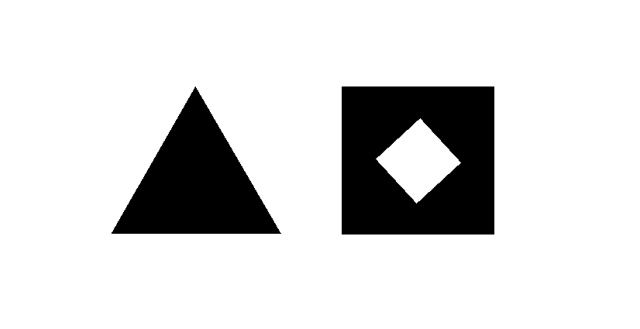

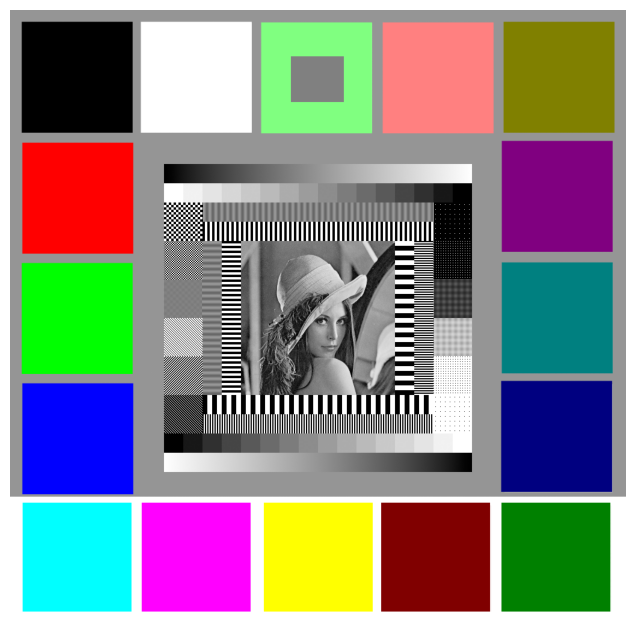

In [135]:
image_path = ["Imagens/shapes.png", "Imagens/testpat.tif"]

for image in image_path:
    show_image(image)

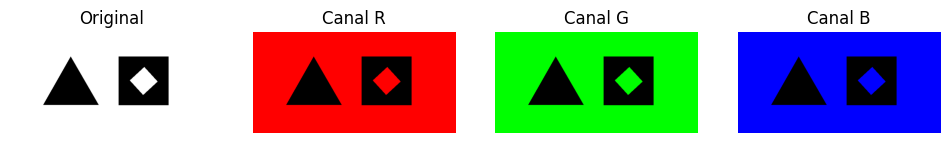

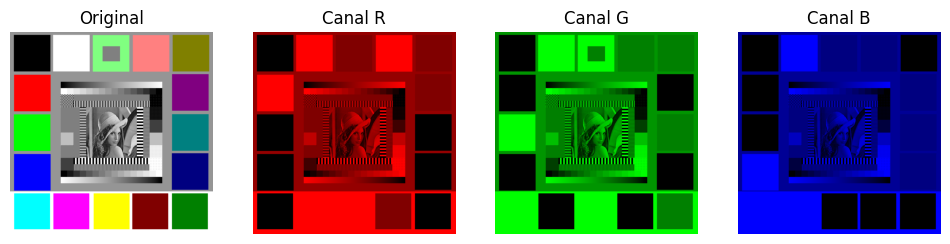

In [136]:
for image in image_path:
    r, g, b, r_color, g_color, b_color, rgb = processar_canais_rgb(image)
    exibir_canais_rgb(r_color, g_color, b_color, rgb)

In [137]:
print("Shape R:", r.shape)
print("Shape G:", g.shape) 
print("Shape B:", b.shape)
print("Tipo R:", type(r), r.dtype)

print("Shape rgb:", rgb.shape)
print("Tipo RGB:", type(rgb), rgb.dtype)


Shape R: (1024, 1024)
Shape G: (1024, 1024)
Shape B: (1024, 1024)
Tipo R: <class 'numpy.ndarray'> uint8
Shape rgb: (1024, 1024, 3)
Tipo RGB: <class 'numpy.ndarray'> uint8


In [138]:
def ler_parametros(filepath: str):
    
    with open(filepath, 'r') as file:
        parametros = json.load(file)
    
    stride = parametros.get("stride")
    dilatacao = parametros.get("dilatacao")
    dimensoes = parametros.get("dimensoes")
    filtro = np.array(parametros.get("filtro"))
    ativacao = parametros.get("ativacao")
    
    return stride, dilatacao, dimensoes, filtro, ativacao

def validar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    erros = []

    if not (1 <= dilatacao <= 5):
        erros.append(f"Dilatação inválida: {dilatacao}. Deve ser um inteiro entre 1 e 5.")

    if not (1 <= stride <= 5):
        erros.append(f"Stride inválido: {stride}. Deve ser um inteiro entre 1 e 5.")

    if len(dimensoes) != 2 or (dimensoes[0] <= 0 or dimensoes[1] <= 0):
        erros.append(f"Dimensões inválidas: {dimensoes}. Deve ser uma lista com dois inteiros positivos [m, n].")

    ativacoes_validas = ["relu", "identity"]
    if ativacao not in ativacoes_validas:
        erros.append(f"Ativação inválida: '{ativacao}'. Deve ser uma das: {ativacoes_validas}.")

    if erros:
        print("Erros encontrados nos parâmetros:")
        for erro in erros:
            print(f"  - {erro}")
        return False
    
    print("Parâmetros válidos!")
    return True

def mostrar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    print("Parâmetros lidos:")
    print(f"Stride: {stride}")
    print(f"Dilatação: {dilatacao}")
    print(f"Dimensões do filtro: {dimensoes}")
    print(f"Filtro:\n{filtro}")
    print(f"Ativação: {ativacao}")

In [139]:
path = "parametros/parametros.json"
stride, dilatacao, dimensoes, filtro, ativacao = ler_parametros(path)
mostrar_parametros(stride, dilatacao, dimensoes, filtro, ativacao)

Parâmetros lidos:
Stride: 2
Dilatação: 2
Dimensões do filtro: [3, 3]
Filtro:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
Ativação: relu


In [140]:
validar_parametros(stride, dilatacao, dimensoes, filtro, ativacao)

Parâmetros válidos!


True

In [141]:
def correlacao_atrous(nome_canal: str, canal: np.ndarray, filtro: np.ndarray, dilatacao: int, stride: int, ativacao: str) -> np.ndarray:
    """
    Aplica correlação atrous (dilatada) em um canal de imagem.
    """
    print(f"Iniciando correlação atrous com canal {nome_canal}")

    altura_img, largura_img = canal.shape
    altura_filtro, largura_filtro = filtro.shape
    print(f"Dimensão do canal: {canal.shape}, Dimensão do filtro: {filtro.shape}")
    
    # 1. Calcula o tamanho efetivo do filtro com a dilatação aplicada
    altura_filtro_dilat = (altura_filtro - 1) * dilatacao + 1
    largura_filtro_dilat = (largura_filtro - 1) * dilatacao + 1
    print(f"Tamanho efetivo do filtro com dilatação: ({altura_filtro_dilat}, {largura_filtro_dilat})")
    
    # 2. Calcula as dimensões da saída corretamente (sem padding)
    altura_dilatada = (altura_img - altura_filtro_dilat) // stride + 1
    largura_dilatada = (largura_img - largura_filtro_dilat) // stride + 1    
    saida = np.zeros((altura_dilatada, largura_dilatada), dtype=np.float32)
    print(f"Dimensão da saída: {saida.shape}")
    
    # 3. Limites do loop atualizados usando o tamanho efetivo
    for i in range(0, altura_img - altura_filtro_dilat + 1, stride):
        for j in range(0, largura_img - largura_filtro_dilat + 1, stride):
            
            soma = 0.0
            
            # Aplica filtro com dilatação r
            for ki in range(altura_filtro):
                for kj in range(largura_filtro):
                    pos_i = i + ki * dilatacao
                    pos_j = j + kj * dilatacao
                    
                    # Sem a necessidade de usar o "if" para checar limites,
                    # pois o novo limite do loop garante que nunca sairemos da imagem.
                    soma += canal[pos_i, pos_j] * filtro[ki, kj]
            
            out_i = i // stride
            out_j = j // stride
            saida[out_i, out_j] = soma
    
    # Aplica função de ativação
    if ativacao == "relu":
        print("Aplicando ReLU")
        saida = np.maximum(0, saida)
    
    # 4. Retornamos em float32 (ou float64) para preservar valores negativos 
    # e permitir o cálculo do valor absoluto nos filtros de Sobel fora desta função.
    return saida

def processar_imagem_rgb(r: np.ndarray, g: np.ndarray, b: np.ndarray, 
                        stride: int, dilatacao: int, filtro: np.ndarray, ativacao: str):
    
    r_out = correlacao_atrous("R", r, filtro, dilatacao, stride, ativacao)
    g_out = correlacao_atrous("G", g, filtro, dilatacao, stride, ativacao)
    b_out = correlacao_atrous("B", b, filtro, dilatacao, stride, ativacao)
    print("Canais processados, saindo tipo: ", r_out.dtype)

    r_color = np.stack([r_out, np.zeros_like(r_out), np.zeros_like(r_out)], axis=2)
    g_color = np.stack([np.zeros_like(g_out), g_out, np.zeros_like(g_out)], axis=2)
    b_color = np.stack([np.zeros_like(b_out), np.zeros_like(b_out), b_out], axis=2)
    print("Canais coloridos criados, saindo tipo: ", r_color.dtype)

    # Exibe os 3 canais processados lado a lado no final
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(r_color)
    axs[0].set_title("Canal R processado")
    axs[0].axis("off")

    axs[1].imshow(g_color)
    axs[1].set_title("Canal G processado")
    axs[1].axis("off")

    axs[2].imshow(b_color)
    axs[2].set_title("Canal B processado")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()
    
    imagem_processada = np.stack([r_out, g_out, b_out], axis=2)
    print("Imagem processada final, tipo: ", imagem_processada.dtype)

    return imagem_processada

In [ ]:
#função manual
stride, dilatacao, dims, filtro_gauss5_5, ativacao = ler_parametros("parametros/gaussiano5_5.json")

mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)
gaussiano_manual = processar_imagem_rgb(r, g, b, 
                                stride, dilatacao, filtro_gauss5_5, ativacao)

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: relu
Iniciando correlação atrous com canal R
Dimensão do canal: (1024, 1024), Dimensão do filtro: (5, 5)
Tamanho efetivo do filtro com dilatação: (5, 5)
Dimensão da saída: (1020, 1020)
Aplicando ReLU
Iniciando correlação atrous com canal G
Dimensão do canal: (1024, 1024), Dimensão do filtro: (5, 5)
Tamanho efetivo do filtro com dilatação: (5, 5)
Dimensão da saída: (1020, 1020)
Aplicando ReLU
Iniciando correlação atrous com canal B
Dimensão do canal: (1024, 1024), Dimensão do filtro: (5, 5)
Tamanho efetivo do filtro com dilatação: (5, 5)
Dimensão da saída: (1020, 1020)


In [ ]:
os.makedirs("resultados", exist_ok=True)
cv2.imwrite(
    "resultados/manual_gaussiano.jpg",
    cv2.cvtColor(gaussiano_manual, cv2.COLOR_RGB2BGR)
)

True

In [ ]:
# função pronta (sem padding: "valid")
img_cv = cv2.imread(image_path[1])
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

ksize = (5, 5)
gaussiano_opencv = cv2.GaussianBlur(img_cv, ksize, sigmaX=1.0)

pad_h = ksize[0] // 2
pad_w = ksize[1] // 2
gaussiano_opencv_nop = gaussiano_opencv[pad_h:-pad_h, pad_w:-pad_w]
print("Dimensão do resultado OpenCV com padding:", gaussiano_opencv.shape)
print("Dimensão do resultado OpenCV sem padding:", gaussiano_opencv_nop.shape)

Dimensão do resultado OpenCV com padding: (1024, 1024, 3)
Dimensão do resultado OpenCV sem padding: (1020, 1020, 3)


In [ ]:
os.makedirs("resultados", exist_ok=True)
cv2.imwrite("resultados/opencv_gaussiano.jpg", cv2.cvtColor(gaussiano_opencv, cv2.COLOR_RGB2BGR))
cv2.imwrite("resultados/opencv_gaussiano_nop.jpg", cv2.cvtColor(gaussiano_opencv_nop, cv2.COLOR_RGB2BGR))

True

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: relu


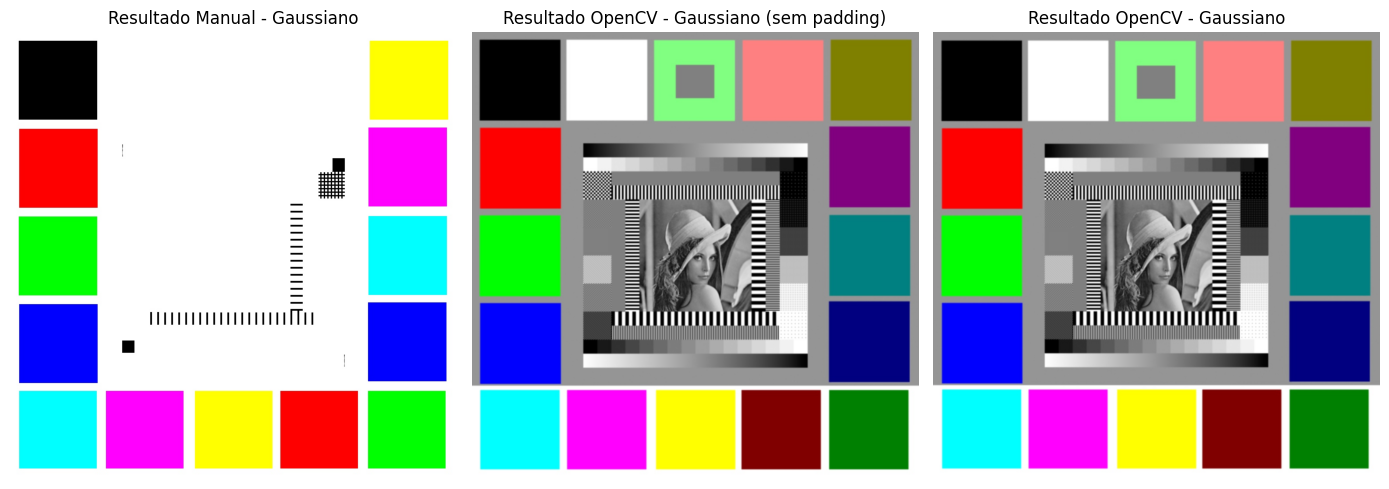

In [ ]:
mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)
img_manual = np.array(Image.open("resultados/manual_gaussiano.jpg"))
img_opencv_nop = np.array(Image.open("resultados/opencv_gaussiano_nop.jpg"))
img_opencv = np.array(Image.open("resultados/opencv_gaussiano.jpg"))

plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_manual)
plt.title("Resultado Manual - Gaussiano")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_opencv_nop)
plt.title("Resultado OpenCV - Gaussiano (sem padding)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_opencv)
plt.title("Resultado OpenCV - Gaussiano")
plt.axis("off")

plt.tight_layout()
plt.show()